# Global and localized learned controllers

`FIGURES_RL.ipynb` trains one learned controller **per household**, on that
household's two training years alone. This notebook asks what changes when the
controllers are trained on **many** households — one global network, or networks
localised to a type of consumer — and where the result lands against the MILP,
the MPC and the best rule. Everything is priced by `hs.summarize`, the study's
own accounting, so a pooled row, a local row, a rule and the MILP are directly
comparable.

### How the pooled and localised models are built

Every model below is the same learner as the local one (`rl_global` is a pooled
port of `rl_control`; a one-household pool reproduces `rl_control.train_dqn` bit
for bit), with the same features (`fc_h24`: causal 14-day-median forecast,
published day-ahead prices, 24 h lookahead, SI contract state), the same
hyperparameters (`run_rl_benchmark.TUNED`, not re-tuned for pooling), the same
behaviour-cloning settings, and the same three-way split applied to **every**
household in a pool: train = days 0–730 minus every 5th week, validation = those
20 weeks, test = days 730–1095 of the 30 study households only, read once by
`run_policy`. Pooling other homes' training years cannot leak the test year.
299 of the 300 Ausgrid households are usable (Ausgrid 2 has an 81-day gap).

| scheme | localisation | data each network sees | how the network knows the type |
|---|---|---|---|
| **local** | to the household | 1 household | it is the only one |
| **global** | none | 299 households | it does not |
| **global + shape-type input** | by input | 299 households | one-hot of the k=30 cluster appended to the observation (not normalised) |
| **per shape type** | by data | the cluster's 1–26 members | separate network per cluster |
| **per shape sub-type** | by data | 3–11 households (KMeans inside a cluster of ≥ 8, on training-year profiles) | separate network |
| **global, fine-tuned per shape type** | by fine-tuning | 299, then the cluster's members | the global-typed weights and scaler, trained on in the type |
| **random pool, shape-type sizes** | none — a *control* | the study household + as many random households as its cluster has members | — |
| **per control type** | by data | ~50 households (k=6) | separate network |
| **global, fine-tuned per control type** | by fine-tuning, with a fallback guard | 299, then the type's members | the global weights; the fine-tune is kept only where it beats them on the type's validation |

**Shape types** are the study's k=30 clustering (`Clustering/Ausgrid/…_30.csv`):
the 72-value weekly load profile, each household normalised by its own maximum,
so shape and nothing else. The 30 study households are the rank-1 member of each.
**Control types** are k=6 clusters on what a battery's dispatch actually depends
on — log annual load and PV-to-load ratio — measured on the training years only.

**Fine-tuning** continues from the global network: a clone at 0.3 × the learning
rate, early-stopped on the type's held-out loss, and kept as the global clone if
that loss never improves; a DQN under the warm-start protection (ε 0.2, half rate),
`bc_dqn` held to the type-localised clone. For control types the DQN fine-tune also
treats the global network as its first candidate, so it cannot hand back weights
that are worse on the type's validation weeks than those it started from.

**Seeds.** A global network drives all 30 households, so its training-seed luck
does not average out across them as 30 local networks' does. The global schemes
were trained under three seeds and are **averaged per household**; every other
scheme is one seed. The local clone was re-trained under two extra seeds as a noise
floor (§2).

In [1]:
import importlib, json, os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon, spearmanr

import hems_study as hs
import figure_style as fs
import run_rl_benchmark as rb
import run_rl_global as rgg
import pv_split as ps
hs, fs, rb, rgg, ps = (importlib.reload(m) for m in (hs, fs, rb, rgg, ps))

import Plotting_Functions as pf
pf = importlib.reload(pf)
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, PLAIN, PCT, finish

# ---- the study's own frame: rules, MILP family, local learners, pooled ones ----
# Every row goes through `hs.summarize` unchanged, so a pooled model, a local
# one, a rule and the MILP are priced by the same accounting: the bill (plus,
# on SI, the standing charge on the contract the controller's own peaks
# agreed), the pack as an NPV at 5 % over min(12 y, 6000 EFC).
df_study = hs.collect_results()
MPC_BEST_ARM = {t: hs.best_mpc_arm(df_study, t) for t in hs.REFERENCE_ARM}
wide = hs.merge_best_mpc(df_study, MPC_BEST_ARM)
wide = wide[wide.arm.isin(hs.REFERENCE_ARM.values())].reset_index(drop=True)
wide = hs.merge_learned_controllers(
    wide, controllers=[(m, "fc_h24") for m in rgg.METHODS], verbose=False)
POOLED = ("global", "global_typed", "type", "rand_type", "global_ft", "subtype",
          "ctrl_type", "ctrl_ft")
wide = rgg.merge_pooled(wide, POOLED)
long = hs.summarize(wide)
long["ident"] = long["dataset"].str.split().str[-1].astype(int)
TARIFFS = ("AU", "SI")

# ---- names ----
METHOD_NAME = {"bc": "IL", "bc_dqn": "IL+RL", "dqn": "RL"}
SCHEME_NAME = {
    "fc_h24": "per household (local)",
    "global": "global, 299 households",
    "global_typed": "global + shape-type input",
    "type": "per shape type (k=30)",
    "rand_type": "random pool, shape-type sizes",
    "global_ft": "global, fine-tuned per shape type",
    "subtype": "per shape sub-type",
    "ctrl_type": "per control type (k=6)",
    "ctrl_ft": "global, fine-tuned per control type",
}


def split_learned(c):
    """'bc_dqn_global_typed' -> ('bc_dqn', 'global_typed'), else None."""
    for m in ("bc_dqn", "dqn", "bc"):
        if c.startswith(m + "_") and c[len(m) + 1:] in SCHEME_NAME:
            return m, c[len(m) + 1:]
    return None


# The best rule is picked per tariff ex post, on the median net saving of the
# scored year -- the same convention `best_mpc_arm` uses for the MPC. An ex-post
# best of seven favours the rule, which is the conservative direction for any
# claim that a learner beats it. `price_oracle` reads the whole year's prices
# (a diagnostic, never deployable) and is excluded.
def best_rbc(tariff):
    sub = long[(long.tariff == tariff)
               & long.controller.map(lambda c: fs.ctrl_family(c) == "RBC")
               & ~long.controller.isin(["price_oracle", "no_battery"])]
    return sub.groupby("controller")["saving_annual_net"].median().idxmax()


BEST_RBC = {t: best_rbc(t) for t in TARIFFS}


def label(c, tariff):
    s = split_learned(c)
    if s:
        return f"{METHOD_NAME[s[0]]}, {SCHEME_NAME[s[1]]}"
    if c == "milp_full":
        return "MILP, full year, perfect foresight"
    if c == "oracle":
        return "MPC 24 h, perfect forecast"
    if c == "mpc_best":
        kind = hs.forecaster_kind_of(MPC_BEST_ARM[tariff])
        return f"MPC 24 h, {ps.forecast_label(kind)} (best realistic)"
    if c == BEST_RBC[tariff]:
        return f"{hs.controller_label(c, 48)} (best RBC)"
    return hs.controller_label(c, 48)


REFS = lambda t: ["milp_full", "oracle", "mpc_best", BEST_RBC[t]]
print("best RBC:", BEST_RBC, "| best realistic MPC:",
      {t: hs.forecaster_kind_of(a) for t, a in MPC_BEST_ARM.items()})
# `wear_eur` is the life-limited wear `summarize` charges -- zero unless the
# cycling would end the pack before its 12-y calendar life. (`wear_shadow_eur`
# is the dispatch price, reported and never billed.)
print("pack priced as NPV; rows whose cycling ends the pack early:",
      int((long["wear_eur"].fillna(0) > 0).sum()))

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  mpc_best: AU <- AU_H24_hbd_median14 (hbd_median14), 30 row(s)
  mpc_best: SI <- SI_H24_hbd_median14 (hbd_median14), 30 row(s)
pooled controllers joined (seeds averaged): bc_global x3, dqn_global x3, bc_dqn_global x3, bc_global_typed x3, dqn_global_typed x3, bc_dqn_global_typed x3, bc_type x3, dqn_type x1, bc_dqn_type x1, bc_rand_type x1, bc_global_ft x1, dqn_global_ft x1, bc_dqn_global_ft x1, bc_subtype x1, dqn_subtype x1, bc_dqn_subtype x1, bc_ctrl_type x1, dqn_ctrl_type x1, bc_dqn_ctrl_type x1, bc_ctrl_ft x1, dqn_ctrl_ft x1, bc_dqn_ctrl_ft x1


best RBC: {'AU': 'price_rank_daily', 'SI': 'self_consumption_peak_shaving'} | best realistic MPC: {'AU': 'hbd_median14', 'SI': 'hbd_median14'}
pack priced as NPV; rows whose cycling ends the pack early: 0


## 1. Where the pooled controllers land

Against the full-year MILP (perfect foresight over the whole year), the 24 h MPC
on a **perfect** forecast, the 24 h MPC on the **best realistic** forecast
(`hems_study.best_mpc_arm`: the deployable forecast arm with the best median net
saving, `hbd_median14` on both tariffs), and the **best rule** (picked the same
way, ex post, so the comparison favours the rule). The axis is the battery's
lifetime NPV; the table below adds the mean net saving per year, its share of the
MILP's, and paired win counts.

**AU.** The global clones reach ~91 % of the MILP's saving (IL global 257, IL
fine-tuned per shape type 260 AUD/a, against 284 for the MILP and 283 for the
perfect-forecast MPC), up from 80 % for the local clone (228). They beat the best
realistic MPC (187) on all 30 households, and sit just below the best rule,
`price_rank_daily` (265), which they beat on 3–7 of 30 households.

**SI.** The global clones save 56 EUR/a (52 % of the MILP's 108), up from 49 for
the local clone, beat the best realistic MPC (32) on 29–30 of 30 households, and
stay well short of the best rule, `self_consumption_peak_shaving` (72), and of the
perfect-forecast MPC (74). The SI gap to the rule is not about pooling: the
training reward prices energy and excess power but not the standing charge on the
agreed kW, which is where SI's money is (see `FIGURES_RL.ipynb` §6). Pooling does
not change what the reward can see.

Pure RL is the exception throughout: pooled DQN saves less than local DQN on both
tariffs, and on SI collapses towards idling (39–40 EFC/a against 88).

findfont: Failed to find font weight semibold, now using 700.


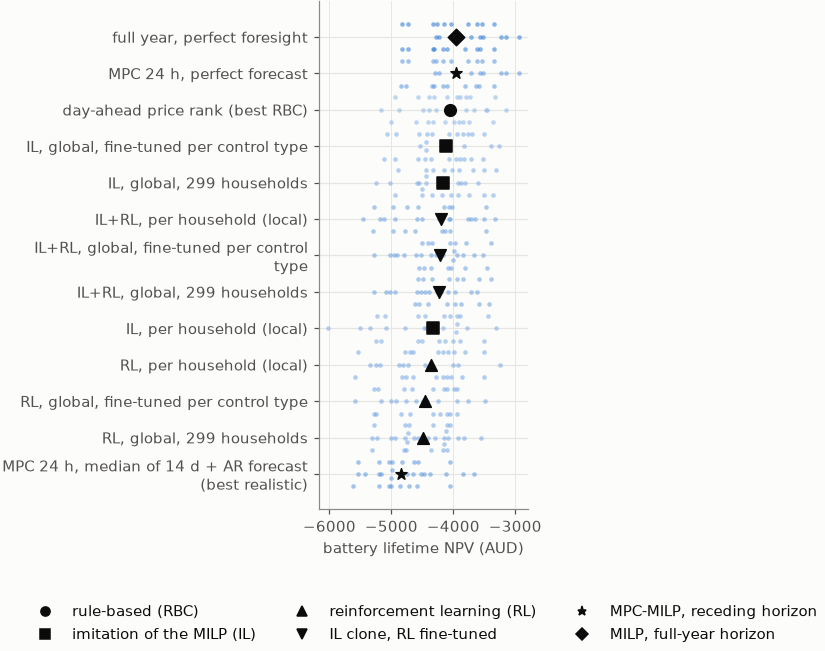

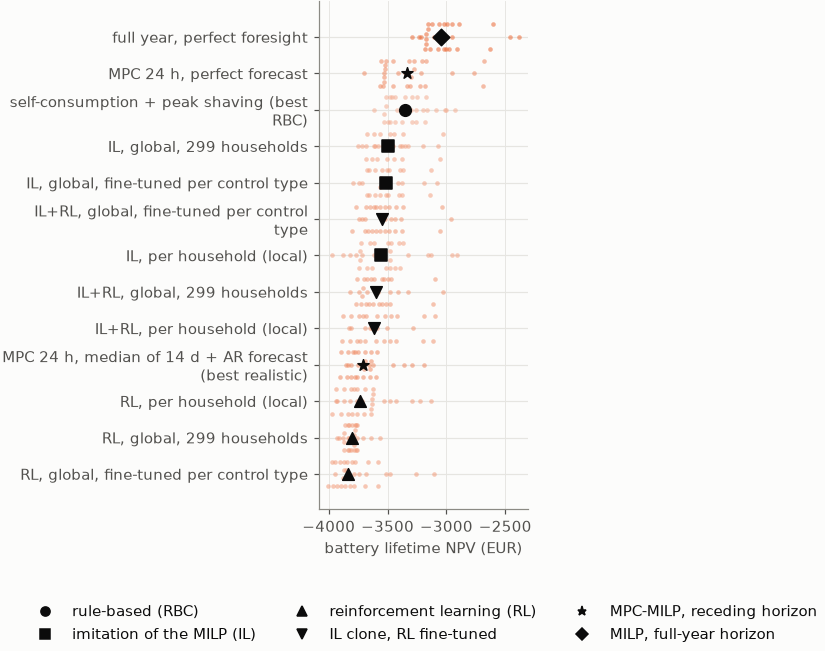

In [2]:
# Ranked on the study's axis, the lifetime NPV of the battery. One figure per
# tariff (a shared row would give each ranking half a column). The learned rows
# shown are the deployable ones a reader would choose between: the local model,
# the global one, and the control-type localisation with its fallback guard.
SHOW = ["fc_h24", "global", "ctrl_ft"]
for tariff in TARIFFS:
    rows = REFS(tariff) + [f"{m}_{s}" for m in ("bc", "bc_dqn", "dqn") for s in SHOW]
    sub = long[(long.tariff == tariff) & long.controller.isin(rows)]
    order = (sub.groupby("controller")["npv"].median().sort_values()
             .index.tolist())
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.85))
    for row, c in enumerate(order):
        v = sub.loc[sub.controller == c, "npv"].to_numpy()
        ax.scatter(v, row + fs.beeswarm(v), s=9, alpha=0.55, linewidths=0,
                   color=fs.ctrl_color(tariff, c), zorder=2)
        ax.scatter([np.median(v)], [row], marker=fs.ctrl_marker(c), s=58,
                   color=INK, zorder=3)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([fs.tick_label(c, {c: label(c, tariff)}, width=40)
                        for c in order])
    # Five-digit tick labels on a narrow axis run into each other at 5.
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    fams = [f for f in ("RBC", "IL", "RL", "IL+RL", "MPC", "MILP")
            if any(fs.ctrl_family(c) == f for c in order)]
    pf.key_legend(ax, [Line2D([], [], marker=fs.FAMILY_MARKER[f], ls="",
                              color=INK, label=fs.FAMILY_LABEL[f]) for f in fams],
                  where="below", ncol=3)
    finish(ax, title=f"{tariff}: pooled learners against the MILP, the MPC and the best rule",
           xlabel=f"battery lifetime NPV ({hs.money(tariff)})", ylabel="")
    pf.show(fig, f"rlg_ranking_{tariff.lower()}")

In [3]:
# The whole roster as numbers. `% of MILP` is the mean net saving as a share of
# the full-year MILP's on the same households -- how much of what perfect
# foresight and a year-long plan can extract a controller gets. The two
# right-hand columns are paired counts: on how many of the 30 households the
# controller's net saving beats the best rule / the best realistic MPC.
def roster(tariff):
    sub = long[(long.tariff == tariff) & (long.controller != "no_battery")]
    w = sub.pivot(index="ident", columns="controller", values="saving_annual_net")
    milp = w["milp_full"].mean()
    learned = [c for c in w.columns if split_learned(c)]
    cols = REFS(tariff) + sorted(learned, key=lambda c: -w[c].mean())
    return pd.DataFrame({
        "controller": [label(c, tariff) for c in cols],
        "median NPV": [sub[sub.controller == c]["npv"].median() for c in cols],
        "mean net saving / a": [w[c].mean() for c in cols],
        "% of MILP": [100 * w[c].mean() / milp for c in cols],
        "beats best RBC": [int((w[c] > w[BEST_RBC[tariff]]).sum()) for c in cols],
        "beats best MPC": [int((w[c] > w["mpc_best"]).sum()) for c in cols],
        "EFC / a": [sub[sub.controller == c]["efc"].mean()
                    if "efc" in sub else np.nan for c in cols],
    })


ROSTER = {t: roster(t) for t in TARIFFS}
with pd.option_context("display.width", 200, "display.max_colwidth", 60):
    for t in TARIFFS:
        print(f"\n{t}  ({hs.money(t, 'year')} for savings; seeds averaged where "
              f"a scheme has three)")
        print(ROSTER[t].round({"median NPV": 0, "mean net saving / a": 1,
                               "% of MILP": 1, "EFC / a": 0}).to_string(index=False))


AU  (AUD/year for savings; seeds averaged where a scheme has three)
                                             controller  median NPV  mean net saving / a  % of MILP  beats best RBC  beats best MPC  EFC / a
                     MILP, full year, perfect foresight     -3952.0                283.9      100.0              30              30    236.0
                             MPC 24 h, perfect forecast     -3955.0                283.1       99.7              30              30    236.0
MPC 24 h, median of 14 d + AR forecast (best realistic)     -4843.0                187.3       66.0               0               0    234.0
                   RBC: day-ahead price rank (best RBC)     -4046.0                264.5       93.2               0              30    218.0
                  IL, global, fine-tuned per shape type     -4096.0                260.3       91.7               7              30    223.0
                IL, global, fine-tuned per control type     -4121.0                25

## 2. Pooled against local, household by household

Each row is the per-household difference in annual net saving, pooled minus
local, mean and 95 % bootstrap interval; filled marker = significant after Holm
over the tariff's rows. The **grey rows and band** are the noise floor: the
*local* clone re-trained under another seed against itself. A row inside that
band is indistinguishable from re-rolling the local model — and note that one
re-roll (AU seed 1, +6.2 AUD/a, raw p 0.03) would pass an uncorrected test on
its own.

- **Imitation gains from pooling, on both tariffs.** AU: global +29.7, global
  with type input +30.2, fine-tuned per control type +30.4 AUD/a (p_holm ≤ 0.002,
  22–23 of 30 households). SI: +6.4 to +7.0 EUR/a (p_holm 0.05–0.19).
- **Per shape type, per sub-type and random pools of the same sizes are all
  inside the noise floor of the local model** — they neither gain nor lose
  against it.
- **Pooled pure RL loses**: AU −8 to −17, SI −12 to −19 per year depending on the
  scheme. This is a property of DQN on pooled data, not of localisation: it is as
  bad for the unlocalised global network as for the localised ones.

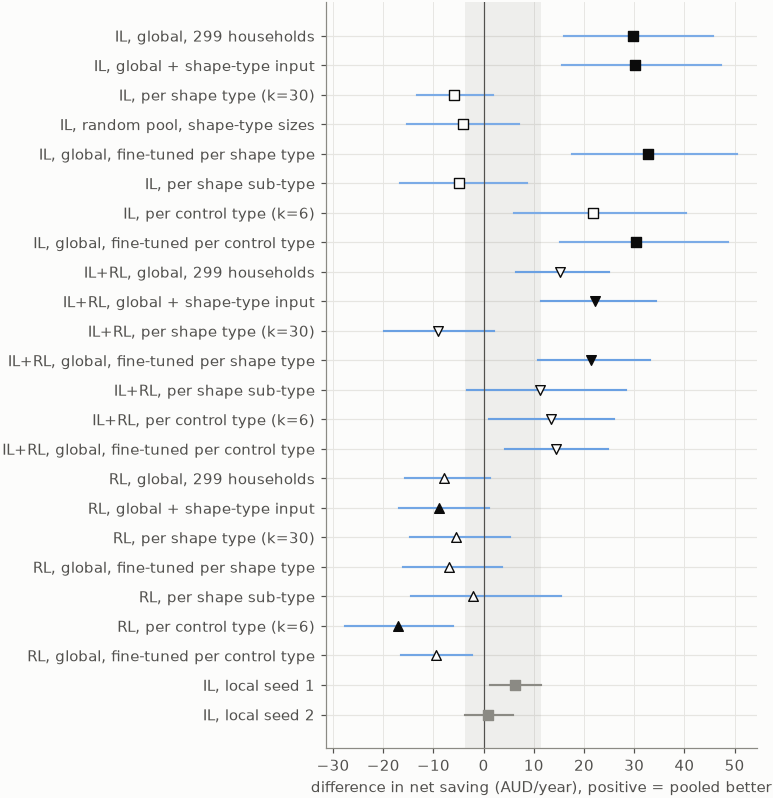

AU
method       scheme  n    mean      lo     hi  pooled better     p  p_holm
    bc       global 30  29.731  16.071 45.763             23 0.000   0.000
    bc global_typed 30  30.150  15.627 47.227             22 0.000   0.001
    bc         type 30  -5.872 -13.277  1.914             10 0.105   0.734
    bc    rand_type 30  -4.166 -15.317  7.102             12 0.221   0.883
    bc    global_ft 30  32.707  17.689 50.516             22 0.000   0.001
    bc      subtype 15  -4.963 -16.574  8.674              5 0.389   0.991
    bc    ctrl_type 30  21.881   6.017 40.319             20 0.020   0.216
    bc      ctrl_ft 30  30.389  15.177 48.660             22 0.000   0.002
bc_dqn       global 30  15.154   6.384 24.957             21 0.008   0.114
bc_dqn global_typed 30  22.245  11.466 34.265             23 0.000   0.006
bc_dqn         type 30  -9.004 -19.768  2.161             12 0.124   0.745
bc_dqn    global_ft 30  21.346  10.797 33.130             23 0.000   0.006
bc_dqn      subtype 15

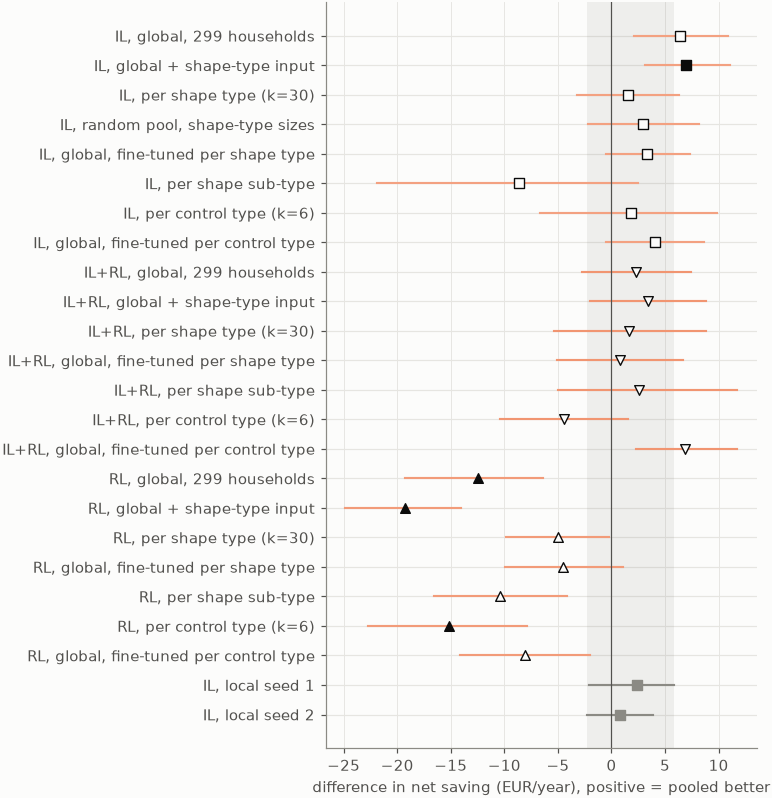

SI
method       scheme  n    mean      lo      hi  pooled better     p  p_holm
    bc       global 30   6.428   2.143  10.830             20 0.010   0.189
    bc global_typed 30   6.969   3.160  11.046             22 0.002   0.046
    bc         type 30   1.510  -3.234   6.345             18 0.503   1.000
    bc    rand_type 30   2.905  -2.175   8.125             16 0.416   1.000
    bc    global_ft 30   3.351  -0.474   7.369             18 0.140   1.000
    bc      subtype 15  -8.606 -21.870   2.503              8 0.454   1.000
    bc    ctrl_type 30   1.860  -6.706   9.833             21 0.171   1.000
    bc      ctrl_ft 30   4.106  -0.476   8.618             19 0.114   1.000
bc_dqn       global 30   2.328  -2.717   7.464             18 0.280   1.000
bc_dqn global_typed 30   3.406  -1.968   8.862             19 0.229   1.000
bc_dqn         type 30   1.640  -5.351   8.866             19 0.452   1.000
bc_dqn    global_ft 30   0.785  -5.039   6.668             17 0.641   1.000
bc_dqn   

In [4]:
# Paired difference in annual net saving, pooled minus local (positive = the
# pooled model saves more), mean over the 30 households with a 95 % bootstrap
# interval. Filled = significant after Holm over every row of the tariff.
#
# The two grey rows are the NOISE FLOOR: the local clone re-trained under seed
# 1 and seed 2, against the published seed-0 clone -- same data, same
# settings, different initialisation. Any row inside their spread is
# indistinguishable from re-rolling the local model.
seeds_local = pd.read_csv(os.path.join(rgg.OUT, "local_seeds.csv"))


def paired_rows(tariff):
    w = (long[long.tariff == tariff]
         .pivot(index="ident", columns="controller", values="saving_annual_net"))
    rows = []
    for m in ("bc", "bc_dqn", "dqn"):
        for s in POOLED:
            c = f"{m}_{s}"
            if c not in w:
                continue
            d = (w[c] - w[f"{m}_fc_h24"]).dropna()
            rows.append({"method": m, "scheme": s, "d": d.to_numpy(),
                         "n": len(d)})
    # Noise floor: saving = -(total cost) with wear zero on every run, so a
    # seed's change in saving is minus its change in the bill.
    sl = seeds_local[(seeds_local.tariff == tariff) & (seeds_local.method == "bc")]
    sw = sl.pivot(index="ident", columns="seed", values="cost_eur_total")
    for s in (1, 2):
        rows.append({"method": "bc", "scheme": f"local seed {s}",
                     "d": -(sw[s] - sw[0]).to_numpy(), "n": len(sw)})
    out = pd.DataFrame(rows)
    out["mean"] = out.d.map(np.mean)
    ci = out.d.map(lambda v: fs.boot_ci(v, stat=np.mean))
    out["lo"], out["hi"] = ci.map(lambda x: x[0]), ci.map(lambda x: x[1])
    out["p"] = out.d.map(lambda v: wilcoxon(v).pvalue if (v != 0).sum() >= 6
                         else np.nan)
    out["p_holm"] = fs.holm(out.p.tolist())
    out["pooled better"] = out.d.map(lambda v: int((v > 0).sum()))
    return out


PAIRED = {t: paired_rows(t) for t in TARIFFS}
for tariff in TARIFFS:
    P = PAIRED[tariff]
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=1.05))
    y = np.arange(len(P))[::-1]
    for yi, (_, r) in zip(y, P.iterrows()):
        noise = r.scheme.startswith("local seed")
        col = MUTED if noise else fs.ctrl_color(tariff, f"{r.method}_x")
        sig = (r.p_holm == r.p_holm) and r.p_holm < 0.05
        ax.plot([r.lo, r.hi], [yi, yi], color=col if not noise else MUTED, lw=1.4)
        ax.scatter([r["mean"]], [yi], marker=fs.FAMILY_MARKER[
                       fs.ctrl_family(f"{r.method}_x")], s=40, zorder=3,
                   facecolor=(INK if sig else SURFACE) if not noise else MUTED,
                   edgecolor=INK if not noise else MUTED, lw=0.9)
    lo_n = P[P.scheme.str.startswith("local seed")][["lo"]].min().iloc[0]
    hi_n = P[P.scheme.str.startswith("local seed")][["hi"]].max().iloc[0]
    ax.axvspan(lo_n, hi_n, color=MUTED, alpha=0.12, lw=0)
    ax.axvline(0, color=INK_2, lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{METHOD_NAME[r.method]}, {SCHEME_NAME.get(r.scheme, r.scheme)}"
                        for _, r in P.iterrows()])
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: pooled minus local, per household",
           xlabel=f"difference in net saving ({hs.money(tariff, 'year')}), "
                  f"positive = pooled better", ylabel="")
    pf.show(fig, f"rlg_paired_vs_local_{tariff.lower()}")
    print(tariff)
    print(P[["method", "scheme", "n", "mean", "lo", "hi", "pooled better",
             "p", "p_holm"]].round(3).to_string(index=False))

## 3. Why localising to the shape types cannot help

Why the per-shape-type models give back the global model's gain:

1. **The shape types do not separate what the dispatch depends on.** The k=30
   clusters leave 86 % of the population's variance in annual load and *more than
   100 %* of the variance in PV and PV/load inside the types — on PV they know
   nothing. That is by construction: each household is normalised by its own
   peak, so the clustering sees when a house uses power, not how much, and never
   sees the roof. The control types (k=6) leave 20 % of the load and 43 % of the
   PV/load variance.
2. **So the type input carries no usable information.** Driving the typed global
   network with a *wrong* shape type changes individual households' bills (mean
   |Δ| 4–24 per year) but not on average (1–3 per year): the network reacts to
   the input, in no consistent direction.
3. **And a per-type pool is, for the controller, a random sample of ~10
   households.** The random-pool control proves it: pools drawn at random with
   the same sizes score the same as the shape-type pools (AU −33.9 vs −35.6
   AUD/a against the global model; SI −3.5 vs −4.9 EUR/a). The per-type deficit is
   the cost of training on 1/30 of the data, nothing else.
4. **Validation could not have flagged it.** On each household's own 20
   validation weeks every clone — local, per type, global — scores within 1–3
   per 140 days of the others; the 30-AUD/a difference appears only in the test
   year (Spearman ρ between the two gaps 0.25–0.5). The clones' advantage from
   pooling is robustness to a year the training years did not contain, which a
   held-out week from inside those years cannot measure. For DQN, by contrast,
   validation does see the pooled deficit (ρ up to 0.73).

             shape type (k=30)  control type (k=6)
annual load               0.86                0.20
annual PV                 1.15                1.20
PV / load                 1.09                0.43


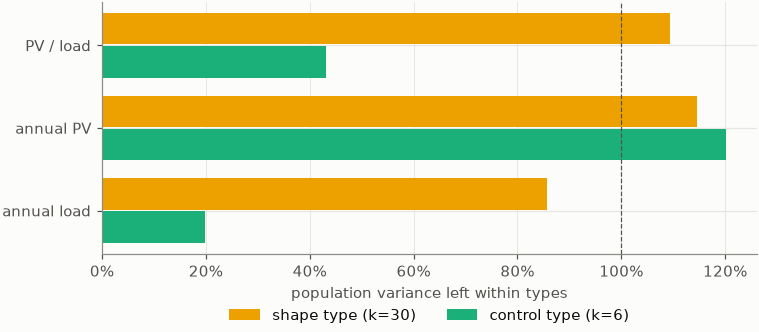

In [5]:
# How much of the variance in what DECIDES a battery's dispatch each typing
# leaves INSIDE its types. 1.0 = the typing knows nothing about that quantity
# (a random split leaves the full variance in every group); 0 = it separates
# households completely. Over the 299 pooled households, training years only.
scale = rgg.household_scale()
scale["shape type (k=30)"] = rgg.population().loc[scale.index, "cluster"]
scale["control type (k=6)"] = rgg.control_types().loc[scale.index, "ctrl_type"]
QTY = {"load_kwh_a": "annual load", "pv_kwh_a": "annual PV",
       "pv_ratio": "PV / load"}
share = pd.DataFrame({typing: {lab: scale.groupby(typing)[q].var().mean()
                                    / scale[q].var() for q, lab in QTY.items()}
                      for typing in ("shape type (k=30)", "control type (k=6)")})
print(share.round(2).to_string())

fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.45))
yy = np.arange(len(share))
for j, (typing, col) in enumerate(zip(share.columns, (SERIES[3], SERIES[2]))):
    ax.barh(yy + (0.2 if j == 0 else -0.2), 100 * share[typing], height=0.38,
            color=col, label=typing)
ax.axvline(100, color=INK_2, lw=0.8, ls="--")   # = what a random split leaves
ax.set_yticks(yy)
ax.set_yticklabels(share.index)
ax.grid(axis="x", color=pf.GRID, lw=0.6)
ax.set_axisbelow(True)
pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=2)
finish(ax, title="What each typing leaves unexplained",
       xlabel="population variance left within types", ylabel="",
       xfmt=PCT)
pf.show(fig, "rlg_type_variance")

In [6]:
# Does the one-hot TYPE input do anything? The seed-0 typed global model is
# driven over the test year twice per household: with its true shape type and
# with a wrong one (cluster + 15). If the network used the input, the wrong
# type would cost money.
wt = rgg.wrong_type_test()
wtp = wt.pivot_table(index=["tariff", "method", "ident"], columns="type_input",
                     values="cost_eur_total")
summary = (wtp["wrong"] - wtp["true"]).groupby(level=[0, 1]).agg(
    mean="mean", abs_mean=lambda v: v.abs().mean(), max_abs=lambda v: v.abs().max())
print("test-year bill, WRONG type minus TRUE type (EUR or AUD / a):")
print(summary.round(2).to_string())

# And could a deployment have seen the pooled-vs-local gap BEFORE the test
# year? Every model, rolled on each household's own validation weeks.
uv = pd.read_csv(rgg.UNIT_VAL)
loc = uv[uv.scheme == "local"].set_index(["tariff", "ident", "method"])["val_net"]
res = rgg.load_results()
res["ident"] = res.ident.astype(int)
m = uv[uv.scheme != "local"].merge(
    res[["tariff", "ident", "scheme", "method", "seed", "cost_eur_total",
         "local_cost_eur_total"]], on=["tariff", "ident", "scheme", "method", "seed"])
m["val_gap"] = m.val_net.values - loc.reindex(
    list(zip(m.tariff, m.ident, m.method))).values
m["test_gap"] = m.cost_eur_total - m.local_cost_eur_total
vt = (m.groupby(["tariff", "method", "scheme"])
      .apply(lambda q: pd.Series({
          "val gap (140 d)": q.val_gap.mean(), "test gap (365 d)": q.test_gap.mean(),
          "rho": spearmanr(q.val_gap, q.test_gap)[0]}), include_groups=False))
print("\npooled minus local cost, validation weeks vs test year "
      "(positive = pooled costs more):")
print(vt.round(2).to_string())

test-year bill, WRONG type minus TRUE type (EUR or AUD / a):
               mean  abs_mean  max_abs
tariff method                         
AU     bc      1.27      3.66    20.83
       bc_dqn  1.10      6.76    27.32
       dqn     2.97     23.62    82.64
SI     bc      0.42      5.37    20.37
       bc_dqn -0.68      9.91    30.27
       dqn    -2.69      5.07    38.82

pooled minus local cost, validation weeks vs test year (positive = pooled costs more):
                            val gap (140 d)  test gap (365 d)   rho
tariff method scheme                                               
AU     bc     ctrl_ft                 -1.17            -30.39  0.46
              ctrl_type               -0.59            -21.88  0.60
              global                   0.34            -29.73  0.31
              global_ft               -1.36            -32.71  0.49
              global_typed             0.25            -30.15  0.25
              rand_type                1.92              4.17  

## 4. Localising to what the controller cares about

Localised minus **global** (positive = the localisation improves on the global
model it refines), per household. The last row of each method is the deployable
fallback taken one step further: per household, the control-type fine-tune or the
global model, **whichever was cheaper on that household's own validation weeks**.

- **Localisation by fine-tuning is never significantly worse than global** —
  on either typing, either tariff, any method. The one significant effect is a
  gain: SI IL+RL fine-tuned per control type, +4.5 EUR/a (24 of 30, p_holm
  0.008), +3.4 with the household-level fallback (p_holm 0.011).
- **Localisation by restricting the data is what costs money**, and how much
  tracks the pool size, not the typing: −35.6 AUD/a for per-shape-type IL
  (~10 households), −33.9 for random pools of the same size, −7.8 for per-control-
  type (~50 households, p_holm 0.04), 0 for global (299).

So the answer to "localisation should not be worse" is: done as a refinement of
the global model, it is not; done by training a separate network on each type's
share of the data, it is, because these learners are data-limited and a type is
1/6–1/30 of the data.

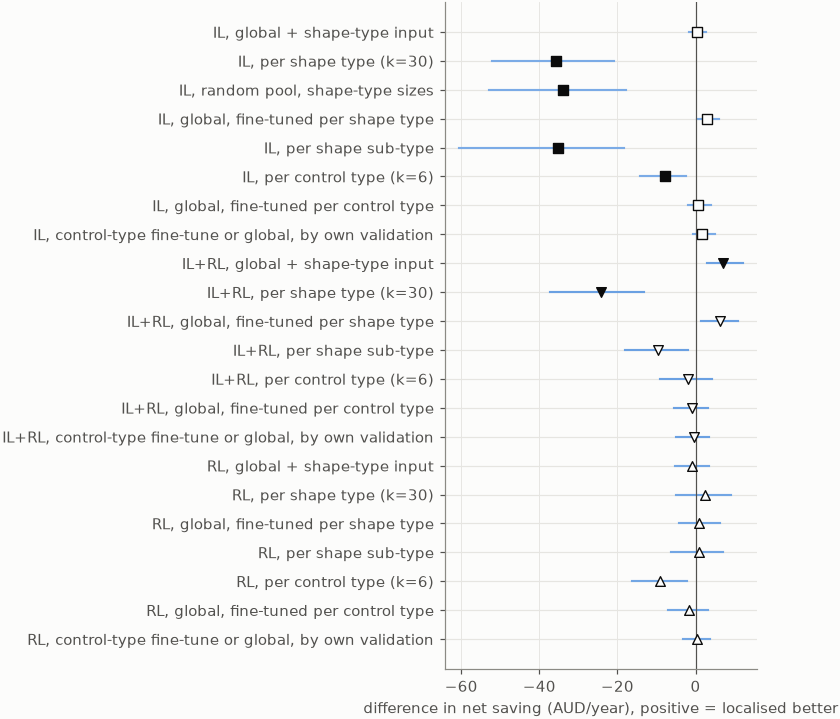

AU
method                                                 row  picked    mean     p  p_holm  better than global
    bc                           global + shape-type input     NaN   0.420 0.685   1.000                  13
    bc                               per shape type (k=30)     NaN -35.602 0.000   0.000                   5
    bc                       random pool, shape-type sizes     NaN -33.897 0.000   0.001                   7
    bc                   global, fine-tuned per shape type     NaN   2.976 0.070   0.849                  20
    bc                                  per shape sub-type     NaN -35.316 0.000   0.001                   0
    bc                              per control type (k=6)     NaN  -7.849 0.002   0.040                   7
    bc                 global, fine-tuned per control type     NaN   0.658 0.262   1.000                   8
    bc control-type fine-tune or global, by own validation    23.0   1.749 0.951   1.000                   8
bc_dqn          

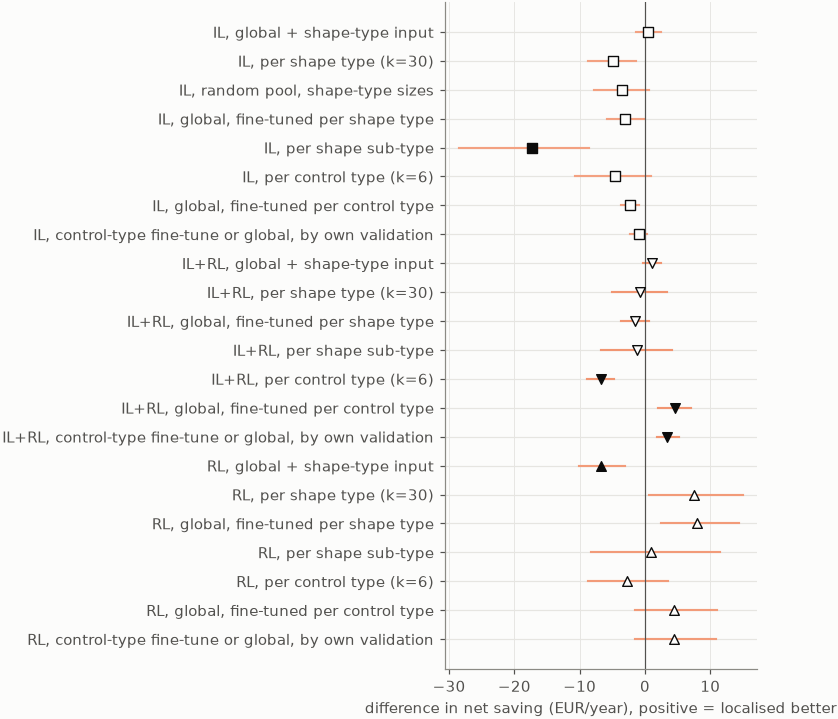

SI
method                                                 row  picked    mean     p  p_holm  better than global
    bc                           global + shape-type input     NaN   0.541 0.968   1.000                  14
    bc                               per shape type (k=30)     NaN  -4.919 0.013   0.205                   9
    bc                       random pool, shape-type sizes     NaN  -3.523 0.152   1.000                  13
    bc                   global, fine-tuned per shape type     NaN  -3.077 0.033   0.458                   9
    bc                                  per shape sub-type     NaN -17.275 0.000   0.008                   2
    bc                              per control type (k=6)     NaN  -4.568 0.404   1.000                  13
    bc                 global, fine-tuned per control type     NaN  -2.322 0.008   0.138                  11
    bc control-type fine-tune or global, by own validation    18.0  -0.953 0.231   1.000                   8
bc_dqn          

In [7]:
# Localised minus GLOBAL (positive = the localisation saves more than the
# global model it is meant to improve on), per household, seeds of the global
# model averaged. The last row per method is the deployable fallback: per
# household, the control-type fine-tune or the global model, whichever was
# cheaper on that household's OWN validation weeks -- a choice made without
# the test year.
def vs_global(tariff):
    w = (long[long.tariff == tariff]
         .pivot(index="ident", columns="controller", values="saving_annual_net"))
    v = uv[(uv.tariff == tariff)]
    rows = []
    for meth in ("bc", "bc_dqn", "dqn"):
        g = w[f"{meth}_global"]
        for s in ("global_typed", "type", "rand_type", "global_ft", "subtype",
                  "ctrl_type", "ctrl_ft"):
            c = f"{meth}_{s}"
            if c in w:
                d = (w[c] - g).dropna()
                rows.append({"method": meth, "row": SCHEME_NAME[s], "d": d})
        # The guarded choice, household by household.
        vg = v[(v.scheme == "global") & (v.method == meth)].groupby("ident").val_net.mean()
        vf = v[(v.scheme == "ctrl_ft") & (v.method == meth)].set_index("ident").val_net
        if len(vf):
            pick_ft = (vf < vg.reindex(vf.index))
            chosen = w[f"{meth}_ctrl_ft"].where(pick_ft.reindex(w.index), g)
            rows.append({"method": meth, "row": "control-type fine-tune or global, "
                         "by own validation", "d": (chosen - g).dropna(),
                         "picked": int(pick_ft.sum())})
    out = pd.DataFrame(rows)
    out["mean"] = out.d.map(np.mean)
    out["p"] = out.d.map(lambda v: wilcoxon(v).pvalue if (v != 0).sum() >= 6 else np.nan)
    out["p_holm"] = fs.holm(out.p.tolist())
    out["better than global"] = out.d.map(lambda v: int((v > 0).sum()))
    return out


for tariff in TARIFFS:
    V = vs_global(tariff)
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.95))
    y = np.arange(len(V))[::-1]
    for yi, (_, r) in zip(y, V.iterrows()):
        lo, hi = fs.boot_ci(r.d.to_numpy(), stat=np.mean)
        sig = (r.p_holm == r.p_holm) and r.p_holm < 0.05
        ax.plot([lo, hi], [yi, yi], color=fs.ctrl_color(tariff, f"{r.method}_x"), lw=1.4)
        ax.scatter([r["mean"]], [yi], marker=fs.FAMILY_MARKER[fs.ctrl_family(f"{r.method}_x")],
                   s=40, zorder=3, facecolor=INK if sig else SURFACE, edgecolor=INK, lw=0.9)
    ax.axvline(0, color=INK_2, lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{METHOD_NAME[r.method]}, {r.row}" for _, r in V.iterrows()])
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: localised minus global, per household",
           xlabel=f"difference in net saving ({hs.money(tariff, 'year')}), "
                  f"positive = localised better", ylabel="")
    pf.show(fig, f"rlg_localised_vs_global_{tariff.lower()}")
    print(tariff)
    print(V.drop(columns="d").round(3).to_string(index=False))

## 5. What this does and does not show

- **Shown:** pooling households helps imitation-based controllers substantially
  on AU and modestly on SI; the gain survives three seeds and a seed-noise floor;
  localising by fine-tuning keeps it; localising by restricting data loses it in
  proportion to the data lost; the study's shape clusters are not control-relevant.
- **Not shown:** that pooled pure RL can work — it was run on the hyperparameters
  tuned for the local learner, and a pooled re-tune was not done. Every scheme
  except `global` / `global_typed` is one seed. SI training is blind to the
  contract standing charge, which caps every learned SI result below the
  peak-shaving rule regardless of pooling.
- **Selection.** The best rule and the best realistic MPC are chosen ex post on
  the test year, which favours them; no learned scheme was chosen on the test year
  (the fallback row selects on validation only).
- **Reproduce:** `python3 run_rl_global.py --phase cache|train|eval|report` with
  `--schemes`, `--seed`; `rgg.unit_validation()`, `rgg.local_seed_runs()`,
  `rgg.wrong_type_test()` for §2–§4. Everything is cached by digest.